In [107]:
# --! include root folders into PYTHONPATH --!

import os
import sys

dir_this = os.getcwd()
dir_example = os.path.abspath(os.path.join(dir_this, '..'))
sys.path.append(dir_example)
dir_root = os.path.abspath(os.path.join(dir_this, '..', '..', '..'))
sys.path.append(dir_root)

import torch
import torch.nn.functional as F
import numpy as np
from matplotlib import pyplot as plt

import example_mujoco
import util_data
import util_nn

data_path = '../../../data/mujoco'
model_path = '../../../models/mujoco'
result_path = '../../../results/mujoco'

### Creating baseline dataset

In [2]:
data_nsample = 918
data = util_data.read_datafile(f'{data_path}/walker2d_baseline_0', data_nsample)
print(f'read data shape: {data.shape}')

obs_ndim = 17
act_ndim = 6
obs, act = torch.split(data, [obs_ndim, act_ndim], dim=-1)
print(f'read observations shape: {obs.shape}')
print(f'read actions shape: {act.shape}')

std_min = torch.tensor(1e-3, dtype=torch.float32)

# --! get normalization constants per observation
obs_mean = [s.mean() for s in torch.split(obs, 1, dim=-1)]
obs_std = [torch.maximum(s.std(), std_min) for s in torch.split(obs, 1, dim=-1)]

# --! normalize observations
obs = torch.cat([
    example_mujoco.normalize_standard(
        s, mean, std) for s, mean, std in zip(torch.split(obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

train_obs = obs[:, :-1]
train_next_obs = obs[:, 1:]
train_act = act[:, :-1]
print(f'shape of observations for training: {train_obs.shape}')
print(f'shape of next observations for training: {train_next_obs.shape}')
print(f'shape of actions for training: {train_act.shape}')

dataloaders = []
nmodel = 5

for _ in range(nmodel):
    dataset = example_mujoco.baseline_dataset(train_obs, train_act, train_next_obs)
    dataloaders.append(torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True))

read data shape: torch.Size([80, 918, 23])
read observations shape: torch.Size([80, 918, 17])
read actions shape: torch.Size([80, 918, 6])
shape of observations for training: torch.Size([80, 917, 17])
shape of next observations for training: torch.Size([80, 917, 17])
shape of actions for training: torch.Size([80, 917, 6])


### Training an ensemble of models

In [3]:
model = example_mujoco.model_ensemble(nmodel, obs_ndim, act_ndim)
example_mujoco.train_ensemble(model, dataloaders, nepoch=300)

0 [array([-0.06806399]), array([-0.06671585]), array([-0.07029857]), array([-0.06634837]), array([-0.06884008])]
10 [array([-0.22640347]), array([-0.22684007]), array([-0.23942411]), array([-0.21610844]), array([-0.24333196])]
20 [array([-0.5321279]), array([-0.4907567]), array([-0.54846253]), array([-0.51476636]), array([-0.54838285])]
30 [array([-0.62642541]), array([-0.63806958]), array([-0.57508702]), array([-0.64227161]), array([-0.60820174])]
40 [array([-0.72775307]), array([-0.71206269]), array([-0.69574814]), array([-0.70865064]), array([-0.69684448])]
50 [array([-0.74170728]), array([-0.59004793]), array([-0.70744357]), array([-0.73086486]), array([-0.5533062])]
60 [array([-0.53397799]), array([-0.72753639]), array([-0.64917922]), array([-0.77425718]), array([-0.74528642])]
70 [array([-0.76195569]), array([-0.62527313]), array([-0.76884599]), array([-0.70123138]), array([-0.76760206])]
80 [array([-0.77006993]), array([-0.73944225]), array([-0.78804703]), array([-0.79482608]), 

### Testing model rollout

In [102]:
this_traj = 44
deterministic = False

s0 = obs[this_traj, 0]
rollout_traj = example_mujoco.rollout_ensemble(model, s0, act[this_traj], deterministic=deterministic)
print(f'rollout shape: {rollout_traj.shape}')

rollout shape: torch.Size([919, 17])


### Plotting rollout results

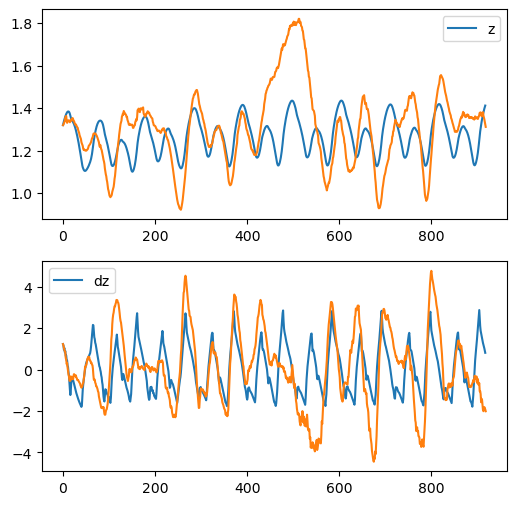

In [103]:
disp_end = rollout_traj.shape[0]
datasaved = False

plot_obs, plot_rollout = example_mujoco.disp_rollout(obs, rollout_traj, obs_mean, obs_std, this_traj, disp_end)

if datasaved:
    rollout_type = 'deterministic' if deterministic else 'stochastic'
    save_step = torch.arange(obs.shape[1]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :disp_end, :1],
        plot_obs[:1, :disp_end, :1], plot_obs[:1, :disp_end, [9]],
        plot_rollout[:1, :disp_end, :1], plot_rollout[:1, :disp_end, [9]]], axis=2)
    util_data.write_datafile(f'{result_path}/walker2d_ensemble_rollout_{rollout_type}', savedata, delim=' ')

In [113]:
traj_mse = []
with torch.no_grad():
    for j in range(obs.shape[0]): # trajectory
        mse = []
        for h in range(1, obs.shape[1]): # horizon
            s0 = obs[j, 0]
            cmp_rollout = example_mujoco.rollout_ensemble(model, s0, act[j, :h], deterministic=False)

            cmp_rollout = torch.unsqueeze(cmp_rollout, 0)
            cmp_rollout = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(cmp_rollout, 1, dim=-1), obs_mean, obs_std)], dim=-1)
            cmp_obs = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(obs[[j], :(h+1)], 1, dim=-1), obs_mean, obs_std)], dim=-1)
            mse.append(F.mse_loss(cmp_rollout, cmp_obs))
        mse = torch.stack(mse)
        traj_mse.append(mse)
    traj_mse = torch.stack(traj_mse)


torch.Size([80, 917])


tensor(0.7044)
tensor(0.6870)


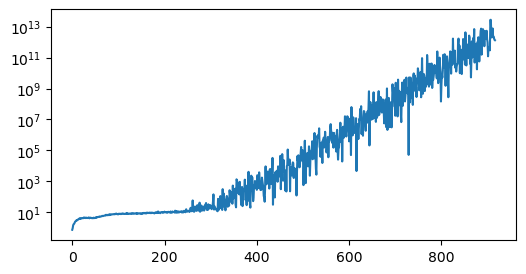

In [134]:
traj_mse_mean = torch.mean(traj_mse, dim=0)
traj_mse_std = torch.std(traj_mse, dim=0)

print(traj_mse_mean[0])
print(traj_mse_std[0])

with torch.no_grad():
    plt.figure(figsize=(6,3))
    plt.semilogy(traj_mse_mean)
    plt.show()

datasaved = False
if datasaved:
    rollout_type = 'deterministic' if deterministic else 'stochastic'
    save_mse_mean = traj_mse_mean.reshape(1, -1, 1)
    save_mse_std = traj_mse_std.reshape(1, -1, 1)
    save_step = torch.arange(traj_mse_mean.shape[0]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :, :1],
        save_mse_mean[:1, :, :1], save_mse_std[:1, :, :1]], axis=2)
    util_data.write_datafile(f'{result_path}/walker2d_ensemble_mse_{rollout_type}', savedata, delim=' ')